# All units are in MW

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [27]:

import glob
# Get a list of all CSV files in the 'data' directory
csv_files = glob.glob('demand data/*.csv')
# Create an empty list to store the dataframes
dfs = []
# Loop through each CSV file, read it into a dataframe, and append it to the list
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)
# Concatenate all dataframes in the list into a single dataframe
merged_df = pd.concat(dfs, ignore_index=True)
# Save the merged dataframe to a new CSV file
merged_df.to_csv('merged_demand_data.csv', index=False)


In [28]:
merged_df[merged_df['SETTLEMENT_DATE'].isna()]

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,SCOTTISH_TRANSFER


In [29]:
merged_df1 = merged_df.drop(columns=['NON_BM_STOR',	'SCOTTISH_TRANSFER', 'IFA_FLOW','IFA2_FLOW', 'BRITNED_FLOW',	'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW', 'NSL_FLOW', 'ELECLINK_FLOW', 'VIKING_FLOW', 'GREENLINK_FLOW'])
print(merged_df1.head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0     01-JAN-2010                  1  36453  37593                 32391   
1     01-JAN-2010                  2  36680  37739                 32590   
2     01-JAN-2010                  3  36343  37467                 32291   
3     01-JAN-2010                  4  35362  36489                 31366   
4     01-JAN-2010                  5  34366  35563                 30522   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                       906                    1786   
1                       926                    1786   
2                       926                    1786   
3                       952                    1786   
4                       952                    1786   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  PUMP_STORAGE_PUMPING  
0                          0                        0                   306  
1                          0                        0   

In [30]:

merged_df1['SETTLEMENT_DATE'] = pd.to_datetime(merged_df1['SETTLEMENT_DATE'], format= 'mixed', errors='coerce')
#merged_df1['Year'] = merged_df1['SETTLEMENT_DATE'].dt.year
#print(f"dtype of column: {merged_df1.dtypes}")

In [31]:
#merged_df1['SETTLEMENT_DATE'] = pd.to_datetime(merged_df1['SETTLEMENT_DATE'], format='%Y-%m-%d')
#merged_df1['SETTLEMENT_DATE'] = merged_df1['SETTLEMENT_DATE'].dt.strftime('%Y-%m-%d')

In [32]:
print(merged_df1.head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0      2010-01-01                  1  36453  37593                 32391   
1      2010-01-01                  2  36680  37739                 32590   
2      2010-01-01                  3  36343  37467                 32291   
3      2010-01-01                  4  35362  36489                 31366   
4      2010-01-01                  5  34366  35563                 30522   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                       906                    1786   
1                       926                    1786   
2                       926                    1786   
3                       952                    1786   
4                       952                    1786   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  PUMP_STORAGE_PUMPING  
0                          0                        0                   306  
1                          0                        0   

In [33]:
print(merged_df1.tail())

       SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
281899      2026-01-29                 44  33935  35418                 31482   
281900      2026-01-29                 45  31873  33079                 29588   
281901      2026-01-29                 46  30217  31208                 28086   
281902      2026-01-29                 47  28193  29157                 26243   
281903      2026-01-29                 48  26709  27676                 24927   

        EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
281899                      3303                    6606   
281900                      3274                    6606   
281901                      3244                    6606   
281902                      3289                    6606   
281903                      3334                    6606   

        EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  \
281899                          0                    21504   
281900                      

In [34]:
merged_df1['FULL_TIMESTAMP'] = merged_df1['SETTLEMENT_DATE'] + (merged_df1['SETTLEMENT_PERIOD'] - 1) * pd.Timedelta(minutes=30)
print(merged_df1.head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0      2010-01-01                  1  36453  37593                 32391   
1      2010-01-01                  2  36680  37739                 32590   
2      2010-01-01                  3  36343  37467                 32291   
3      2010-01-01                  4  35362  36489                 31366   
4      2010-01-01                  5  34366  35563                 30522   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                       906                    1786   
1                       926                    1786   
2                       926                    1786   
3                       952                    1786   
4                       952                    1786   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  PUMP_STORAGE_PUMPING  \
0                          0                        0                   306   
1                          0                        0 

In [35]:
merged_df1['HALF_HOURLY'] = merged_df1['FULL_TIMESTAMP'].dt.time
merged_df1['DAY_OF_WEEK'] = merged_df1['FULL_TIMESTAMP'].dt.dayofweek
merged_df1['MONTH'] = merged_df1['FULL_TIMESTAMP'].dt.month
print(merged_df1.head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0      2010-01-01                  1  36453  37593                 32391   
1      2010-01-01                  2  36680  37739                 32590   
2      2010-01-01                  3  36343  37467                 32291   
3      2010-01-01                  4  35362  36489                 31366   
4      2010-01-01                  5  34366  35563                 30522   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                       906                    1786   
1                       926                    1786   
2                       926                    1786   
3                       952                    1786   
4                       952                    1786   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  PUMP_STORAGE_PUMPING  \
0                          0                        0                   306   
1                          0                        0 

In [36]:
# regional spllit from ND
region_shares = {
    "London": 0.14,
    "South_East": 0.15,
    "South_West": 0.11,
    "Midlands": 0.19,
    "North_West": 0.13,
    "North_East": 0.125,
    "South_Scotland": 0.125,
    "North_Scotland": 0.03
}
for region, share in region_shares.items():
    merged_df1[region] = merged_df1['ND'] * share

In [37]:
#merged_df1["regional_sum"] = merged_df1[["London", "South_East", "South_West", "Midlands", "North_West", "North_East", "South_Scotland", "North_Scotland"]].sum(axis=1)
print(merged_df1.head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0      2010-01-01                  1  36453  37593                 32391   
1      2010-01-01                  2  36680  37739                 32590   
2      2010-01-01                  3  36343  37467                 32291   
3      2010-01-01                  4  35362  36489                 31366   
4      2010-01-01                  5  34366  35563                 30522   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                       906                    1786   
1                       926                    1786   
2                       926                    1786   
3                       952                    1786   
4                       952                    1786   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  PUMP_STORAGE_PUMPING  \
0                          0                        0                   306   
1                          0                        0 

merged_df1[["ND", "regional_sum"]].head()

In [38]:
# Quick analysis example
weekly_avg = merged_df1.groupby('DAY_OF_WEEK')['ENGLAND_WALES_DEMAND'].mean()
print(weekly_avg)

DAY_OF_WEEK
0    28495.451866
1    29125.661278
2    29170.852180
3    29090.147919
4    28507.307112
5    25653.430969
6    25031.034220
Name: ENGLAND_WALES_DEMAND, dtype: float64


In [39]:
# This saves the file to your current working directory
#merged_df1.to_csv('merged_data.csv', index=False)

In [40]:
y = merged_df1[['London', 'South_East', 'South_West', 'Midlands', 'North_West', 'North_East', 'South_Scotland', 'North_Scotland']]

In [41]:
features = ['SETTLEMENT_PERIOD', 'DAY_OF_WEEK', 'MONTH', 'EMBEDDED_WIND_GENERATION', 'EMBEDDED_SOLAR_GENERATION', 'PUMP_STORAGE_PUMPING', 'EMBEDDED_WIND_GENERATION', 'EMBEDDED_SOLAR_GENERATION']
x = merged_df1[features]

In [42]:
# splitting the data into training and testing sets based on date
train = merged_df1[merged_df1['SETTLEMENT_DATE'] < '2023-01-01']
test = merged_df1[merged_df1['SETTLEMENT_DATE'] >= '2023-01-01']
X_train = train[features]
y_train = train[['London', 'South_East', 'South_West', 'Midlands', 'North_West', 'North_East', 'South_Scotland', 'North_Scotland']]
X_test = test[features]
y_test = test[['London', 'South_East', 'South_West', 'Midlands', 'North_West', 'North_East', 'South_Scotland', 'North_Scotland']]

In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
model = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [45]:
pred_merged_df1 = pd.DataFrame(y_pred, columns=y_train.columns)

In [46]:
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')

Mean Absolute Error: 341.05664750159394


In [47]:
#predict test set
y_pred = model.predict(X_test)
#calculate MAE for each region
mae_per_region = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
# Create a readable summary
comparison_merged_df1 = pd.DataFrame({
    'Region': ['London', 'South_East', 'South_West', 'Midlands', 'North_West', 'North_East', 'South_Scotland', 'North_Scotland'],
    'MAE': mae_per_region,
    'Average_Actual_Value': y_test.mean().values
})

# Add a percentage error for context
comparison_merged_df1['Error_Pct'] = (comparison_merged_df1['MAE'] / comparison_merged_df1['Average_Actual_Value']) * 100
print(comparison_merged_df1)
#for region in y_train.columns:
    #region_mae = mean_absolute_error(y_test[region], y_pred[:, y_train.columns.get_loc(region)])
    #print(f'Mean Absolute Error for {region}: {region_mae}')

           Region         MAE  Average_Actual_Value  Error_Pct
0          London  381.983445           3687.849509  10.357891
1      South_East  409.267977           3951.267331  10.357891
2      South_West  300.129850           2897.596042  10.357891
3        Midlands  518.406104           5004.938619  10.357891
4      North_West  354.698913           3424.431686  10.357891
5      North_East  341.056648           3292.722775  10.357891
6  South_Scotland  341.056648           3292.722775  10.357891
7  North_Scotland   81.853595            790.253466  10.357891


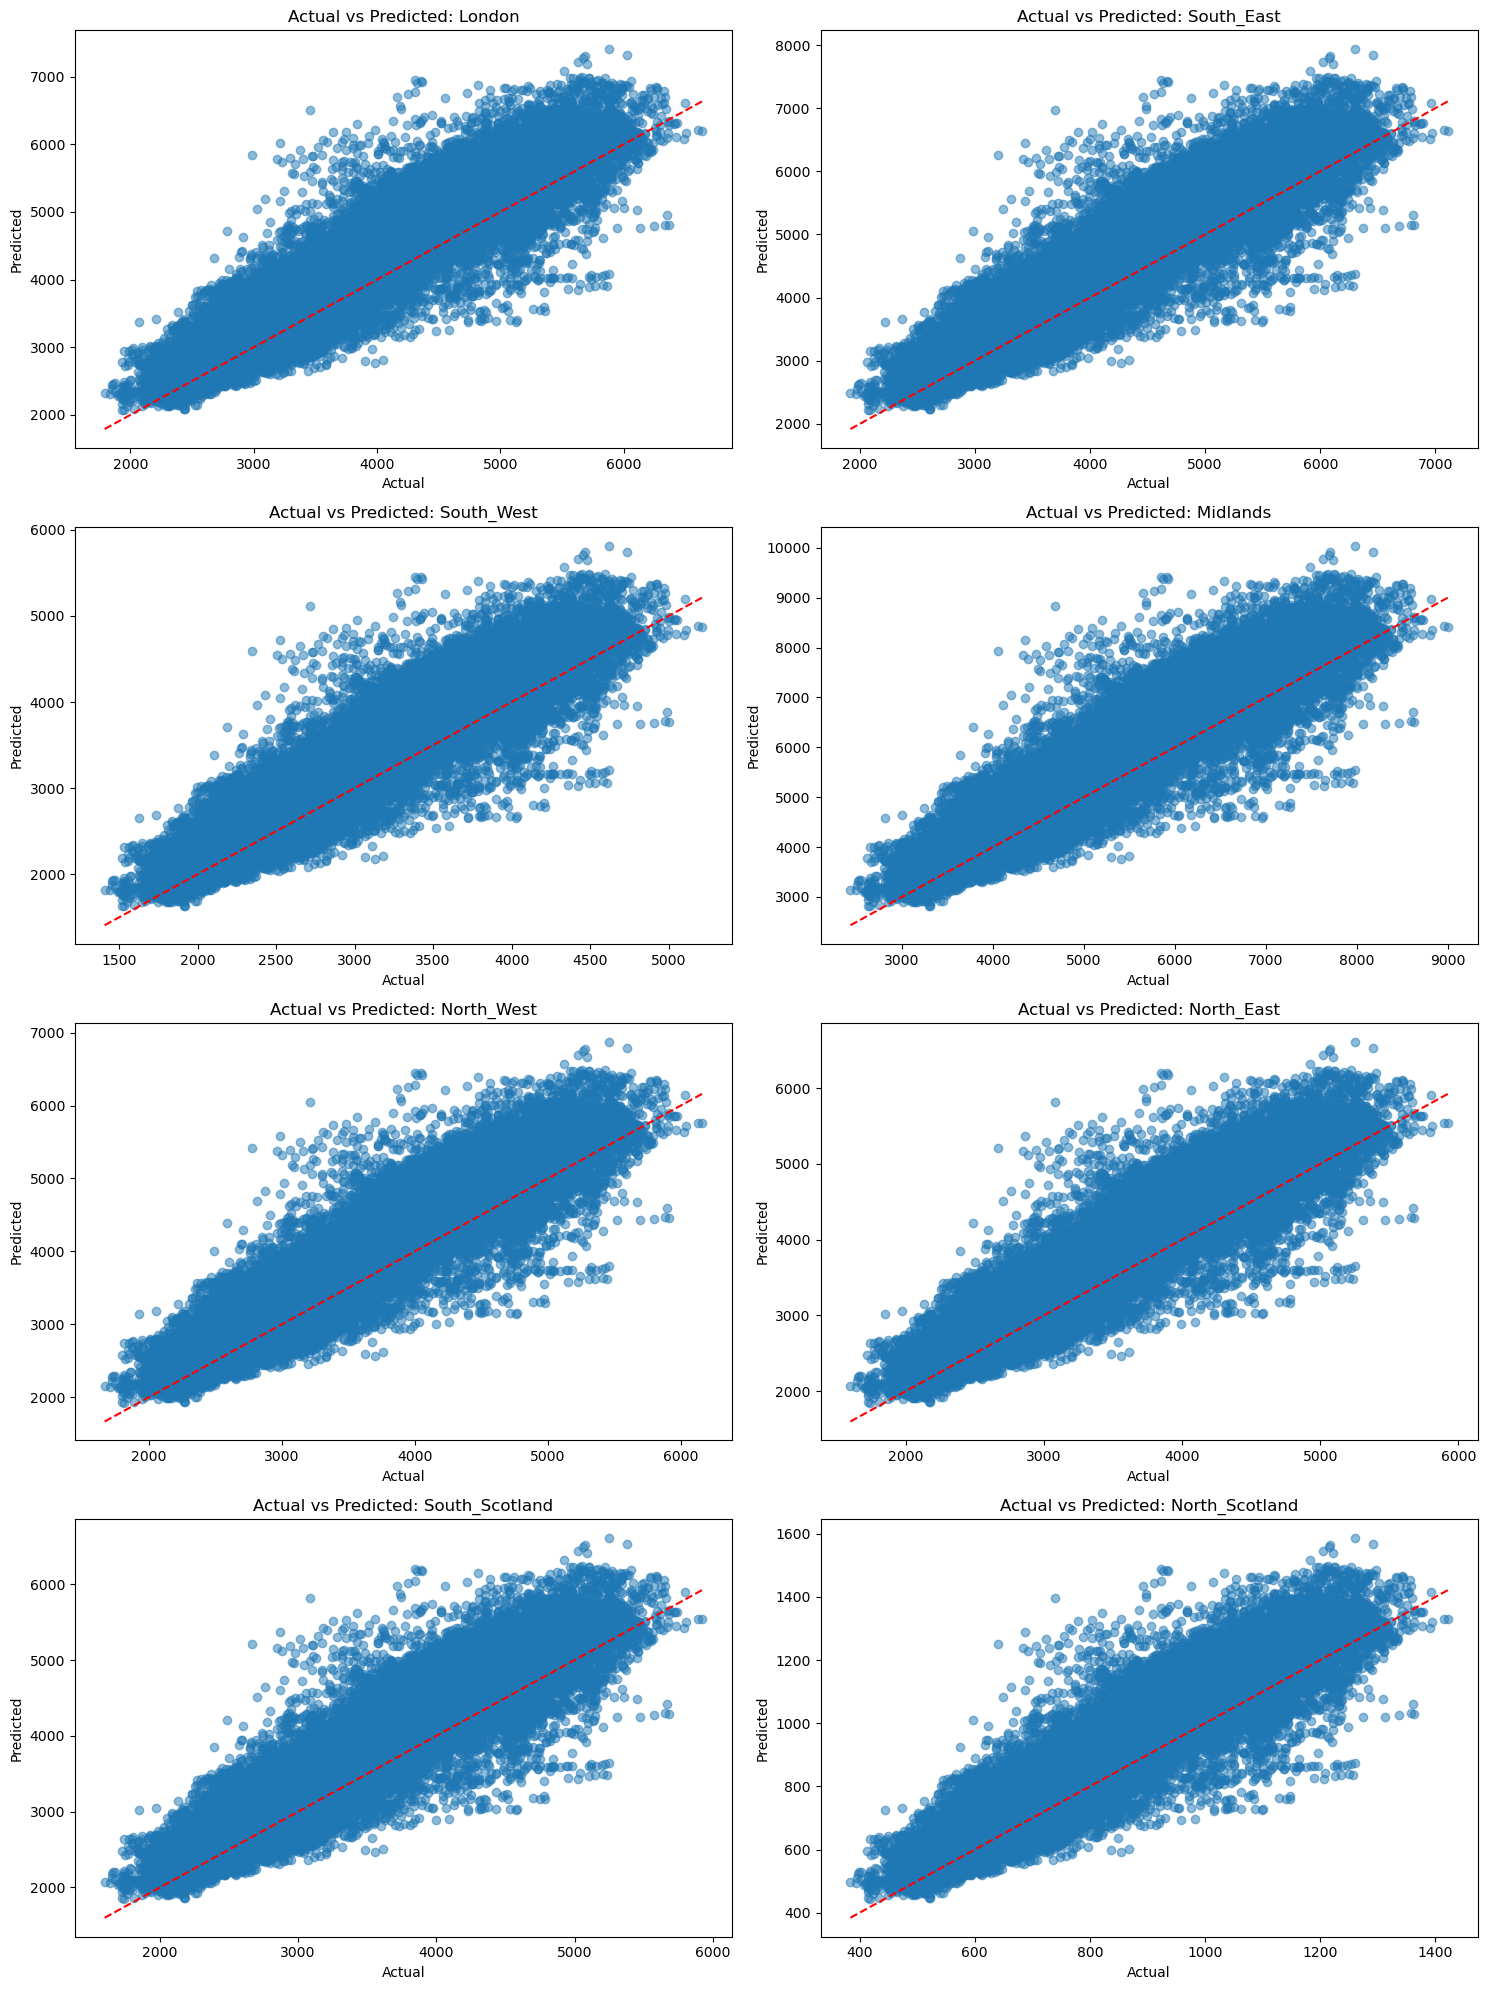

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(y_test.columns):
    axes[i].scatter(y_test[col], y_pred[:, i], alpha=0.5)
    axes[i].plot([y_test[col].min(), y_test[col].max()], [y_test[col].min(), y_test[col].max()], 'r--')
    axes[i].set_title(f'Actual vs Predicted: {col}')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

In [49]:
# Check if regions are identical
correlation_matrix = merged_df1[['London', 'South_East', 'South_West', 'Midlands', 'North_West', 'North_East', 'South_Scotland', 'North_Scotland']].corr()
print(correlation_matrix)

                London  South_East  South_West  Midlands  North_West  \
London             1.0         1.0         1.0       1.0         1.0   
South_East         1.0         1.0         1.0       1.0         1.0   
South_West         1.0         1.0         1.0       1.0         1.0   
Midlands           1.0         1.0         1.0       1.0         1.0   
North_West         1.0         1.0         1.0       1.0         1.0   
North_East         1.0         1.0         1.0       1.0         1.0   
South_Scotland     1.0         1.0         1.0       1.0         1.0   
North_Scotland     1.0         1.0         1.0       1.0         1.0   

                North_East  South_Scotland  North_Scotland  
London                 1.0             1.0             1.0  
South_East             1.0             1.0             1.0  
South_West             1.0             1.0             1.0  
Midlands               1.0             1.0             1.0  
North_West             1.0             1.0    

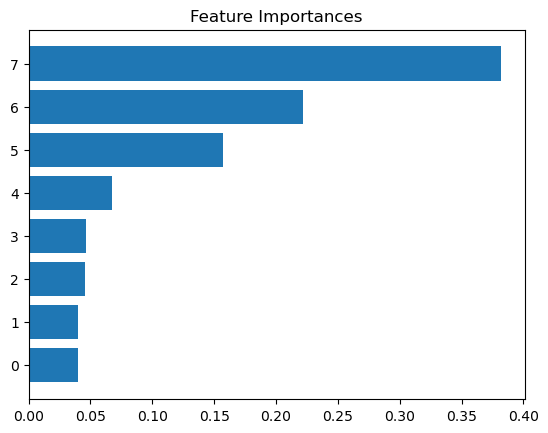

In [50]:


importances = model.feature_importances_
indices = np.argsort(importances)

plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices])
plt.show()